## Fonctions générales et paramètres du modèle

On regroupe d’abord les fonctions et les paramètres utilisés dans tout le traitement.

Les fichiers expérimentaux contiennent les colonnes :

$$
\text{Date},\quad \text{Heure},\quad \text{Temps (s)},\quad T_1,\quad T_2
$$

Les températures $T_1$ et $T_2$ correspondent aux deux thermocouples utilisés pendant les essais.

Le modèle avec glace est représenté par un élément fini linéaire $P_1$ placé entre les deux capteurs. La longueur du domaine est donc la distance entre les deux thermocouples :

$$
L=L_{\mathrm{ice}}
$$

On utilise les fonctions de forme classiques sur l’élément de référence :

$$
\xi\in[-1,1]
$$

avec :

$$
N_1(\xi)=\frac{1-\xi}{2}
$$

et :

$$
N_2(\xi)=\frac{1+\xi}{2}
$$

Le changement de variable entre l’élément de référence et l’élément physique est :

$$
x(\xi)=\frac{L}{2}(1+\xi)
$$

donc :

$$
dx=\frac{L}{2}d\xi
$$

et :

$$
\frac{dN}{dx}
=
\frac{2}{L}
\frac{dN}{d\xi}
$$

Les matrices éléments finis sont ensuite construites numériquement par quadrature de Gauss-Legendre. Cette écriture permet de garder une formulation générale, même si l’on utilise ici un seul élément fini.

La diffusivité thermique $\alpha$ est identifiée par recherche dans un intervalle :

$$
\alpha\in[\alpha_{\min},\alpha_{\max}]
$$

Les valeurs testées sont espacées logarithmiquement afin d’explorer plusieurs ordres de grandeur.

In [ ]:
# ============================================================
# IMPORTS, FONCTIONS GÉNÉRALES ET PARAMÈTRES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

from google.colab import files


# ------------------------------------------------------------
# Paramètres modifiables
# ------------------------------------------------------------

# Distance entre les deux capteurs T1 et T2
L_ice = 79.9 / 1000.0   # [m]

# Intervalle de recherche de la diffusivité thermique
alpha_min = 1.0e-8
alpha_max = 1.0e-4
n_alpha = 250

alpha_values = np.logspace(
    np.log10(alpha_min),
    np.log10(alpha_max),
    n_alpha
)

# ============================================================
# PARAMÈTRES POUR LE CALCUL DES PENTES
# ============================================================

# On utilise seulement la partie droite des courbes pour calculer les pentes.
# 0.5 signifie : on garde la moitié droite de la courbe.
fit_start_fraction_no_ice = 0.5
fit_start_fraction_ice = 0.5


# ============================================================
# LECTURE DES FICHIERS TXT EXPÉRIMENTAUX
# ============================================================

def load_experimental_txt():
    """
    Charge un fichier expérimental au format txt avec les colonnes :
    Date, Heure, Temps (s), T1, T2.

    Compatible avec les décimales écrites avec une virgule.
    """

    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    df = pd.read_csv(
        io.BytesIO(uploaded[file_name]),
        sep=r"\s+",
        engine="python",
        skiprows=1,
        names=["Date", "Heure", "Temps_s", "T1", "T2"]
    )

    # Conversion des virgules décimales en points décimaux
    for col in ["Temps_s", "T1", "T2"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Temps_s", "T1", "T2"]).reset_index(drop=True)

    print("Fichier chargé :")
    print(file_name)
    print(f"Nombre de points lus = {len(df)}")

    display(df.head())
    display(df.tail())

    if len(df) == 0:
        raise ValueError(
            "Aucune donnée numérique valide n'a été lue. "
            "Vérifie le séparateur ou le format du fichier."
        )

    return df, file_name

# ------------------------------------------------------------
# Fonctions de forme P1 sur [-1, 1]
# ------------------------------------------------------------

def lagrange_p1(xi):
    """
    Fonctions de forme P1 sur l'élément de référence [-1, 1].
    """

    N = np.array([
        0.5 * (1.0 - xi),
        0.5 * (1.0 + xi)
    ])

    dN_dxi = np.array([
        -0.5,
         0.5
    ])

    return N, dN_dxi


# ------------------------------------------------------------
# Quadrature de Gauss-Legendre à 2 points
# ------------------------------------------------------------

gauss_points = np.array([
    -1.0 / np.sqrt(3.0),
     1.0 / np.sqrt(3.0)
])

gauss_weights = np.array([1.0, 1.0])


# ------------------------------------------------------------
# Construction FEM pour un élément P1
# ------------------------------------------------------------

def build_one_element_fem_matrices_p1(L, s_loss):
    """
    Construit M, K et F pour un seul élément P1 sur [0,L],
    en utilisant les fonctions de forme en coordonnée locale xi.
    """

    M = np.zeros((2, 2))
    K = np.zeros((2, 2))
    F = np.zeros(2)

    J = L / 2.0

    for xi, w in zip(gauss_points, gauss_weights):

        N, dN_dxi = lagrange_p1(xi)

        dN_dx = dN_dxi / J

        M += w * np.outer(N, N) * J
        K += w * np.outer(dN_dx, dN_dx) * J
        F += w * (-s_loss * N) * J

    return M, K, F


# ============================================================
# SIMULATION DE T1_FEM POUR UN ALPHA DONNÉ
# ============================================================

def simulate_T1_for_alpha(alpha, tau, T1_exp, T2_bc, M, K, F):
    """
    Résout le problème réduit avec :

        T_d(t) = T2_exp(t)       condition aux limites imposée
        T_f(t) = T1_FEM(t)       température calculée

    Le vecteur nodal est ordonné comme :

        T = [T1, T2]

    donc :
        noeud 0 : T1 libre
        noeud 1 : T2 imposé
    """

    alpha = float(alpha)

    T1_fem = np.zeros_like(T1_exp, dtype=float)

    # Condition initiale :
    # on utilise T1(t0) comme température initiale de l'échantillon.
    T1_fem[0] = T1_exp[0]

    # Partition :
    # f = noeud libre T1
    # d = noeud imposé T2
    f = [0]
    d = [1]

    M_ff = M[np.ix_(f, f)]
    M_fd = M[np.ix_(f, d)]

    K_ff = K[np.ix_(f, f)]
    K_fd = K[np.ix_(f, d)]

    F_f = F[f]

    for n in range(len(tau) - 1):

        dt_n = tau[n + 1] - tau[n]

        T_f = np.array([T1_fem[n]])
        T_d = np.array([T2_bc[n]])

        dT_d = np.array([
            (T2_bc[n + 1] - T2_bc[n]) / dt_n
        ])

        rhs = (
            F_f
            - M_fd @ dT_d
            - alpha * (K_ff @ T_f + K_fd @ T_d)
        )

        dT_f = np.linalg.solve(M_ff, rhs)

        T1_fem[n + 1] = T1_fem[n] + dt_n * dT_f[0]

    return T1_fem

# ------------------------------------------------------------
# Ajustement linéaire
# ------------------------------------------------------------

# ============================================================
# AJUSTEMENT LINÉAIRE SUR UNE PARTIE DE LA COURBE
# ============================================================

def extract_right_part(t, y, start_fraction=0.5):
    """
    Extrait la partie droite d'une courbe.

    start_fraction = 0.5 signifie que l'on garde la moitié droite
    de la courbe en temps.
    """

    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    t_min = t[0]
    t_max = t[-1]

    t_start = t_min + start_fraction * (t_max - t_min)

    mask = t >= t_start

    if np.sum(mask) < 2:
        raise ValueError("Pas assez de points dans la fenêtre choisie pour calculer une pente.")

    return t[mask], y[mask], mask


def linear_fit_coeffs(t, y, start_fraction=0.5):
    """
    Ajuste y = b0 + b1 t sur la partie droite de la courbe.
    """

    t_fit, y_fit, mask = extract_right_part(
        t,
        y,
        start_fraction=start_fraction
    )

    b1, b0 = np.polyfit(t_fit, y_fit, deg=1)

    return b0, b1, mask


def linear_slope(t, y, start_fraction=0.5):
    """
    Retourne la pente b1 calculée sur la partie droite de la courbe.
    """

    b0, b1, mask = linear_fit_coeffs(
        t,
        y,
        start_fraction=start_fraction
    )

    return b1

## Identification de la perte diffuse à partir du fichier sans glace

Le fichier sans glace est utilisé pour identifier une perte thermique diffuse effective. Cette perte sera ensuite imposée dans le modèle avec glace.

Dans cette version, on n’utilise pas une température moyenne. La température de référence est directement la température mesurée par le capteur $T_1$ :

$$
T_{\mathrm{ref}}(t)=T_1(t)
$$

Ce choix est retenu car $T_1$ est considéré comme plus représentatif de la température globale de l’échantillon dans cette configuration expérimentale.

Le début utile de l’expérience est défini comme l’instant où $T_1$ atteint son maximum :

$$
t_0=\operatorname*{arg\,max}_t T_1(t)
$$

Les données mesurées avant cet instant correspondent à une phase de mise en place, de chauffage ou de stabilisation du dispositif. Elles ne sont donc pas utilisées pour l’identification de la perte.

On introduit ensuite le temps corrigé :

$$
\tau=t-t_0
$$

Sur la zone utile, on approxime l’évolution de $T_1$ par une droite :

$$
T_1(\tau)\approx a_0+a_1\tau
$$

Le modèle simplifié utilisé pour identifier la perte est :

$$
\frac{dT_1}{dt}=-s_{\mathrm{loss,no\ ice}}
$$

Ainsi, la perte diffuse effective est donnée par :

$$
s_{\mathrm{loss,no\ ice}}=-a_1
$$

Cette perte est exprimée en :

$$
^\circ C/s
$$

Elle sera ensuite utilisée comme terme connu dans le modèle thermique avec glace.

In [ ]:
# ============================================================
# FICHIER SANS GLACE : IDENTIFICATION DE LA PERTE AVEC T1
# ============================================================

print("Charge le fichier SANS glace")
df_no_ice, file_no_ice = load_experimental_txt()

t_no_ice = df_no_ice["Temps_s"].to_numpy(dtype=float)
T1_no_ice = df_no_ice["T1"].to_numpy(dtype=float)
T2_no_ice = df_no_ice["T2"].to_numpy(dtype=float)

# Début utile : maximum de T1
idx0_no_ice = int(np.argmax(T1_no_ice))
t0_no_ice = t_no_ice[idx0_no_ice]
T1_max_no_ice = T1_no_ice[idx0_no_ice]

df_no_ice_useful = df_no_ice.iloc[idx0_no_ice:].copy().reset_index(drop=True)
df_no_ice_useful["tau_s"] = df_no_ice_useful["Temps_s"] - t0_no_ice

tau_no_ice = df_no_ice_useful["tau_s"].to_numpy(dtype=float)

# Température de référence :
# on utilise T1, car elle est plus représentative de la température
# de l'échantillon dans cette configuration.
T_ref_no_ice = df_no_ice_useful["T1"].to_numpy(dtype=float)

# Ajustement linéaire sur la partie droite de T1 :
# T1(tau) = a0 + a1 tau

tau_fit_no_ice, T_ref_fit_no_ice, mask_fit_no_ice = extract_right_part(
    tau_no_ice,
    T_ref_no_ice,
    start_fraction=fit_start_fraction_no_ice
)

a1_no_ice, a0_no_ice = np.polyfit(
    tau_fit_no_ice,
    T_ref_fit_no_ice,
    deg=1
)

T_fit_no_ice = a0_no_ice + a1_no_ice * tau_fit_no_ice

# Perte diffuse effective :
# dT1/dt = -s_loss
s_loss_no_ice = -a1_no_ice

ss_res = np.sum((T_ref_fit_no_ice - T_fit_no_ice)**2)
ss_tot = np.sum((T_ref_fit_no_ice - np.mean(T_ref_fit_no_ice))**2)
R2_no_ice_loss = 1.0 - ss_res / ss_tot

print("Perte diffuse identifiée avec T1 sur la partie droite :")
print(f"a0 = {a0_no_ice:.6e} °C")
print(f"a1 = dT1/dt = {a1_no_ice:.6e} °C/s")
print(f"s_loss_no_ice = {s_loss_no_ice:.6e} °C/s")
print(f"R² = {R2_no_ice_loss:.10f}")
print(f"Début de la fenêtre de pente = {tau_fit_no_ice[0]:.6f} s")

Charge le fichier SANS glace


Saving tube_acier_noice.txt to tube_acier_noice.txt
Fichier chargé :
tube_acier_noice.txt
Nombre de points lus = 817


,Date,Heure,Temps_s,T1,T2
0,06/02/2026,08:26:35,0.287,94.268,82.102
1,06/02/2026,08:26:40,5.288,94.343,85.054
2,06/02/2026,08:26:45,10.288,94.389,87.153
3,06/02/2026,08:26:50,15.288,94.431,88.609
4,06/02/2026,08:26:55,20.289,94.452,89.588


,Date,Heure,Temps_s,T1,T2
812,06/02/2026,09:34:16,4060.695,79.416,78.853
813,06/02/2026,09:34:21,4065.696,79.392,78.846
814,06/02/2026,09:34:26,4070.696,79.371,78.834
815,06/02/2026,09:34:31,4075.696,79.359,78.822
816,06/02/2026,09:34:36,4080.696,79.347,78.789


Perte diffuse identifiée avec T1 sur la partie droite :
a0 = 9.296443e+01 °C
a1 = dT1/dt = -3.395556e-03 °C/s
s_loss_no_ice = 3.395556e-03 °C/s
R² = 0.9990165345
Début de la fenêtre de pente = 2020.205000 s


## Visualisation du fichier sans glace

On trace les deux températures expérimentales :

$$
T_1(t)
$$

et :

$$
T_2(t)
$$

La ligne verticale indique le début utile de l’expérience :

$$
t=t_0
$$

avec :

$$
t_0=\operatorname*{arg\,max}_t T_1(t)
$$

On trace ensuite l’ajustement linéaire réalisé uniquement sur $T_1$ dans la zone utile :

$$
T_1(\tau)\approx a_0+a_1\tau
$$

La pente de cette droite permet d’identifier la perte diffuse effective :

$$
s_{\mathrm{loss,no\ ice}}=-a_1
$$

Il ne s’agit donc pas d’une perte estimée à partir d’une température moyenne, mais d’une perte effective obtenue à partir de la dynamique du capteur $T_1$.

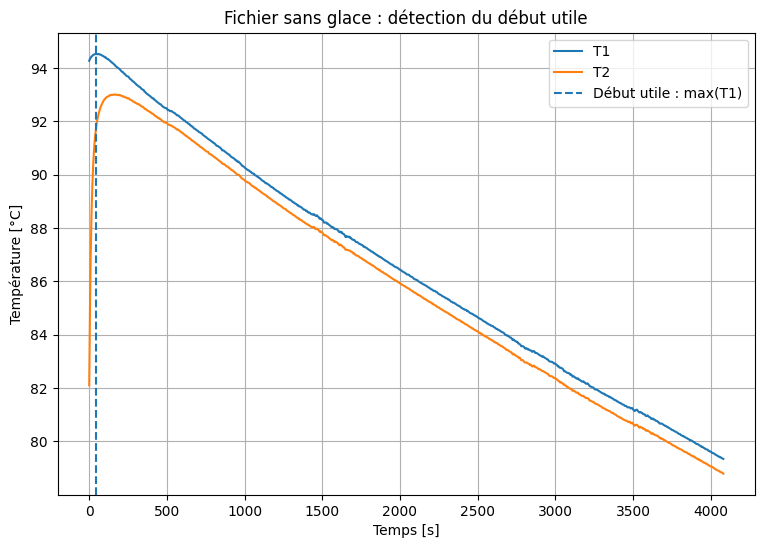

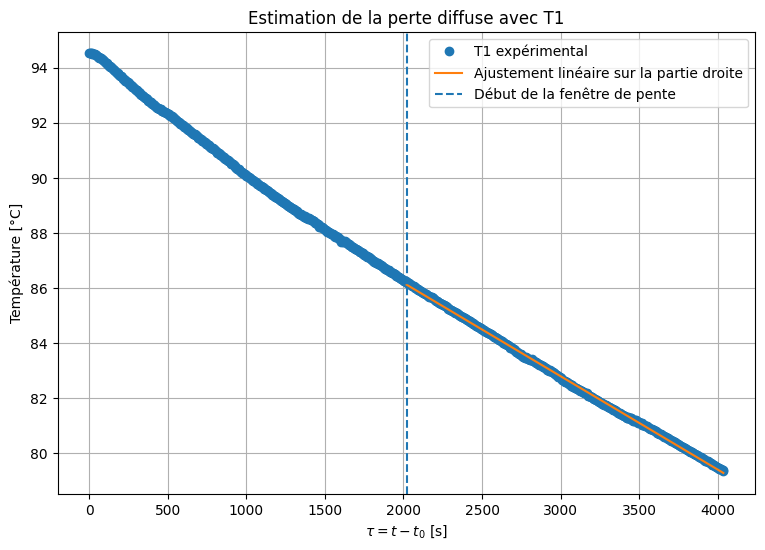

In [ ]:
# ============================================================
# VISUALISATION DU FICHIER SANS GLACE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(t_no_ice, T1_no_ice, label="T1")
plt.plot(t_no_ice, T2_no_ice, label="T2")

plt.axvline(
    t0_no_ice,
    linestyle="--",
    label="Début utile : max(T1)"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température [°C]")
plt.title("Fichier sans glace : détection du début utile")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# VISUALISATION DE L'AJUSTEMENT LINÉAIRE SANS GLACE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    tau_no_ice,
    T_ref_no_ice,
    marker="o",
    linestyle="",
    label="T1 expérimental"
)

plt.plot(
    tau_fit_no_ice,
    T_fit_no_ice,
    label="Ajustement linéaire sur la partie droite"
)

plt.axvline(
    tau_fit_no_ice[0],
    linestyle="--",
    label="Début de la fenêtre de pente"
)

plt.xlabel(r"$\tau = t-t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Estimation de la perte diffuse avec T1")
plt.grid(True)
plt.legend()
plt.show()

## Chargement du fichier avec glace et extraction de la zone utile

Le fichier avec glace est utilisé pour identifier la diffusivité thermique $\alpha$.

Dans ce modèle, la température mesurée par le capteur $T_2$ est utilisée comme condition aux limites imposée :

$$
T_d(t)=T_2^{\mathrm{exp}}(t)
$$

La température $T_1$ est calculée par le modèle éléments finis :

$$
T_f(t)=T_1^{\mathrm{FEM}}(t)
$$

et comparée à la mesure expérimentale :

$$
T_1^{\mathrm{exp}}(t)
$$

Le début utile de l’expérience est défini comme l’instant où $T_1$ atteint son maximum :

$$
t_0=\operatorname*{arg\,max}_t T_1(t)
$$

On introduit le temps corrigé :

$$
\tau=t-t_0
$$

La condition initiale du champ thermique est prise uniforme et égale à la température mesurée par $T_1$ au début utile :

$$
T(x,0)=T_1^{\mathrm{exp}}(t_0)
$$

Dans le cas du modèle à un seul élément, cela revient à initialiser le degré de liberté calculé par :

$$
T_1^{\mathrm{FEM}}(0)=T_1^{\mathrm{exp}}(t_0)
$$

La température $T_2^{\mathrm{exp}}(t)$ est ensuite imposée comme condition aux limites pendant toute la simulation.

Charge le fichier AVEC glace


Saving tube_acier.txt to tube_acier.txt
Fichier chargé :
tube_acier.txt
Nombre de points lus = 231


,Date,Heure,Temps_s,T1,T2
0,05/02/2026,15:33:13,0.285,90.645,34.440
1,05/02/2026,15:33:18,5.284,90.885,31.984
2,05/02/2026,15:33:23,10.285,91.113,30.097
3,05/02/2026,15:33:28,15.286,91.241,27.892
4,05/02/2026,15:33:33,20.286,91.354,27.014


,Date,Heure,Temps_s,T1,T2
226,05/02/2026,15:52:03,1130.396,74.439,11.732
227,05/02/2026,15:52:08,1135.396,74.349,12.024
228,05/02/2026,15:52:13,1140.397,74.263,12.443
229,05/02/2026,15:52:18,1145.397,74.190,12.841
230,05/02/2026,15:52:23,1150.398,74.128,13.095


Fichier avec glace :
tube_acier.txt

Début utile :
idx0 = 12
t0 = 60.289000 s
T1(t0) = 91.676000 °C
T2(t0) = 26.820000 °C
Durée utile = 1090.109000 s


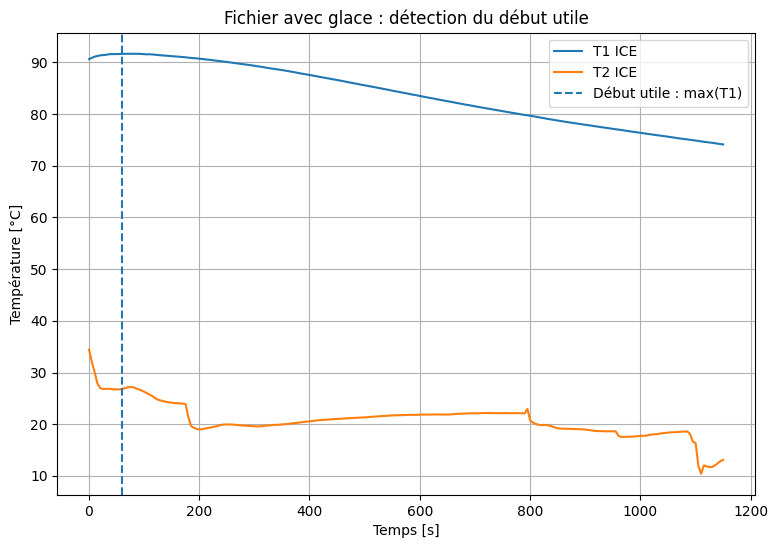

In [ ]:
# ============================================================
# FICHIER AVEC GLACE : CHARGEMENT ET ZONE UTILE
# ============================================================

print("Charge le fichier AVEC glace")
df_ice, file_ice = load_experimental_txt()

t_ice_full = df_ice["Temps_s"].to_numpy(dtype=float)
T1_ice_full = df_ice["T1"].to_numpy(dtype=float)
T2_ice_full = df_ice["T2"].to_numpy(dtype=float)

# Début utile : maximum de T1
idx0_ice = int(np.argmax(T1_ice_full))
t0_ice = t_ice_full[idx0_ice]

df_ice_useful = df_ice.iloc[idx0_ice:].copy().reset_index(drop=True)
df_ice_useful["tau_s"] = df_ice_useful["Temps_s"] - t0_ice

tau_ice = df_ice_useful["tau_s"].to_numpy(dtype=float)

# T1 est la température à reproduire par le FEM
T1_ice_exp = df_ice_useful["T1"].to_numpy(dtype=float)

# T2 est la condition aux limites imposée
T2_ice_bc = df_ice_useful["T2"].to_numpy(dtype=float)

print("Fichier avec glace :")
print(file_ice)
print()
print("Début utile :")
print(f"idx0 = {idx0_ice}")
print(f"t0 = {t0_ice:.6f} s")
print(f"T1(t0) = {T1_ice_exp[0]:.6f} °C")
print(f"T2(t0) = {T2_ice_bc[0]:.6f} °C")
print(f"Durée utile = {tau_ice[-1]:.6f} s")


plt.figure(figsize=(9, 6))

plt.plot(t_ice_full, T1_ice_full, label="T1 ICE")
plt.plot(t_ice_full, T2_ice_full, label="T2 ICE")

plt.axvline(
    t0_ice,
    linestyle="--",
    label="Début utile : max(T1)"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température [°C]")
plt.title("Fichier avec glace : détection du début utile")
plt.grid(True)
plt.legend()
plt.show()


## Construction des matrices éléments finis du cas avec glace

On modélise le domaine entre les deux capteurs par un élément fini linéaire $P_1$.

L’équation thermique utilisée est :

$$
\frac{\partial T}{\partial t}
=
\alpha
\frac{\partial^2T}{\partial x^2}
-
s_d
$$

où :

$$
s_d=s_{\mathrm{loss,no\ ice}}
$$

est la perte diffuse identifiée avec le fichier sans glace.

La forme faible du problème est :

$$
\int_0^L
W
\frac{\partial T}{\partial t}
\,dx
+
\alpha
\int_0^L
\frac{dW}{dx}
\frac{\partial T}{\partial x}
\,dx
=
-
s_d
\int_0^L
W\,dx
$$

Avec la méthode de Galerkin :

$$
W=N_l
$$

et l’approximation :

$$
T^h(x,t)=\sum_m T_m(t)N_m(x)
$$

on obtient le système semi-discret :

$$
M\dot{T}+\alpha KT=F
$$

avec :

$$
M_{lm}
=
\int_0^L
N_lN_m\,dx
$$

$$
K_{lm}
=
\int_0^L
\frac{dN_l}{dx}
\frac{dN_m}{dx}
\,dx
$$

et :

$$
F_l
=
-s_d
\int_0^L
N_l(x)\,dx
$$

Dans le code, ces quantités sont calculées par quadrature de Gauss sur l’élément de référence :

$$
\xi\in[-1,1]
$$

Cette approche évite d’écrire directement les matrices analytiques et garde la structure éléments finis générale.

La somme du vecteur de perte doit vérifier :

$$
\sum_l F_l
=
-s_dL
$$

car la perte agit sur toute la longueur du domaine.

In [ ]:
# ============================================================
# MATRICES FEM DU CAS AVEC GLACE
# ============================================================

s_d = s_loss_no_ice

M_ice, K_ice, F_ice = build_one_element_fem_matrices_p1(
    L=L_ice,
    s_loss=s_d
)

print("Paramètres FEM :")
print(f"L_ice = {L_ice:.6e} m")
print(f"s_d = {s_d:.6e} °C/s")
print()
print("Matrice de masse M :")
print(M_ice)
print()
print("Matrice de rigidité K :")
print(K_ice)
print()
print("Vecteur de perte diffuse F :")
print(F_ice)
print()
print("Vérification de F :")
print(f"Somme numérique = {np.sum(F_ice):.6e}")
print(f"Valeur attendue = {-s_d * L_ice:.6e}")

Paramètres FEM :
L_ice = 7.990000e-02 m
s_d = 3.395556e-03 °C/s

Matrice de masse M :
[[0.02663333 0.01331667]
 [0.01331667 0.02663333]]

Matrice de rigidité K :
[[ 12.51564456 -12.51564456]
 [-12.51564456  12.51564456]]

Vecteur de perte diffuse F :
[-0.00013565 -0.00013565]

Vérification de F :
Somme numérique = -2.713050e-04
Valeur attendue = -2.713050e-04


## Identification de la diffusivité thermique $\alpha$

Le système éléments finis semi-discret s’écrit :

$$
M\dot{T}+\alpha KT=F
$$

Dans le cas avec glace, on sépare le degré de liberté calculé et le degré de liberté imposé :

$$
T_f(t)=T_1^{\mathrm{FEM}}(t)
$$

et :

$$
T_d(t)=T_2^{\mathrm{exp}}(t)
$$

La température $T_2$ est donc une condition aux limites imposée, tandis que $T_1$ est calculée par le modèle.

L’équation associée au degré de liberté libre est :

$$
M_{ff}\dot{T}_f
=
F_f
-
M_{fd}\dot{T}_d
-
\alpha
\left(
K_{ff}T_f+K_{fd}T_d
\right)
$$

où :

$$
F_f
$$

contient la perte diffuse identifiée à partir du fichier sans glace.

Comme $T_d(t)=T_2^{\mathrm{exp}}(t)$ dépend du temps, sa dérivée temporelle ne peut pas être négligée. Elle est estimée par différences finies :

$$
\dot{T}_d^n
\approx
\frac{
T_d^{n+1}-T_d^n
}{
t^{n+1}-t^n
}
$$

Le système est intégré par Euler explicite :

$$
T_f^{n+1}
=
T_f^n
+
\Delta t
M_{ff}^{-1}
\left[
F_f
-
M_{fd}\dot{T}_d^n
-
\alpha
\left(
K_{ff}T_f^n+K_{fd}T_d^n
\right)
\right]
$$

Pour chaque valeur candidate de $\alpha$, le modèle calcule une courbe :

$$
T_1^{\mathrm{FEM}}(t;\alpha)
$$

Cette courbe est comparée à la mesure expérimentale :

$$
T_1^{\mathrm{exp}}(t)
$$

La comparaison ne se fait pas par RMSE entre les profils complets. En effet, le profil simulé peut être décalé par rapport à l’expérience. Le critère retenu porte uniquement sur la pente globale de $T_1$.

On ajuste donc :

$$
T_1^{\mathrm{exp}}(t)\approx b_0^{\mathrm{exp}}+b_1^{\mathrm{exp}}t
$$

et :

$$
T_1^{\mathrm{FEM}}(t;\alpha)\approx b_0^{\mathrm{FEM}}(\alpha)+b_1^{\mathrm{FEM}}(\alpha)t
$$

L’erreur utilisée pour identifier $\alpha$ est l’écart relatif entre les pentes :

$$
\varepsilon_{\mathrm{pente}}(\alpha)
=
\frac{
\left|
b_1^{\mathrm{FEM}}(\alpha)-b_1^{\mathrm{exp}}
\right|
}{
\left|
b_1^{\mathrm{exp}}
\right|
}
$$

La diffusivité thermique retenue est celle qui minimise cet écart relatif :

$$
\alpha^\star
=
\operatorname*{arg\,min}_{\alpha}
\varepsilon_{\mathrm{pente}}(\alpha)
$$

In [ ]:
# ============================================================
# IDENTIFICATION DE ALPHA PAR ÉCART RELATIF DES PENTES
# SUR LA PARTIE DROITE DES COURBES
# ============================================================

slope_T1_exp = linear_slope(
    tau_ice,
    T1_ice_exp,
    start_fraction=fit_start_fraction_ice
)

results_alpha = []

for alpha_value in alpha_values:

    T1_fem_alpha = simulate_T1_for_alpha(
        alpha=alpha_value,
        tau=tau_ice,
        T1_exp=T1_ice_exp,
        T2_bc=T2_ice_bc,
        M=M_ice,
        K=K_ice,
        F=F_ice
    )

    slope_T1_fem = linear_slope(
        tau_ice,
        T1_fem_alpha,
        start_fraction=fit_start_fraction_ice
    )

    abs_slope_error = abs(slope_T1_fem - slope_T1_exp)

    relative_slope_error = abs_slope_error / max(abs(slope_T1_exp), 1e-15)

    results_alpha.append({
        "alpha": alpha_value,
        "slope_T1_exp": slope_T1_exp,
        "slope_T1_fem": slope_T1_fem,
        "abs_slope_error": abs_slope_error,
        "relative_slope_error": relative_slope_error
    })

df_alpha_search = pd.DataFrame(results_alpha)

idx_best_alpha = df_alpha_search["relative_slope_error"].idxmin()

alpha_best = df_alpha_search.loc[idx_best_alpha, "alpha"]
slope_T1_fem_best = df_alpha_search.loc[idx_best_alpha, "slope_T1_fem"]
abs_slope_error_best = df_alpha_search.loc[idx_best_alpha, "abs_slope_error"]
relative_slope_error_best = df_alpha_search.loc[idx_best_alpha, "relative_slope_error"]

T1_fem_best = simulate_T1_for_alpha(
    alpha=alpha_best,
    tau=tau_ice,
    T1_exp=T1_ice_exp,
    T2_bc=T2_ice_bc,
    M=M_ice,
    K=K_ice,
    F=F_ice
)

# Fenêtre utilisée pour la pente
tau_fit_ice, T1_exp_fit_ice, mask_fit_ice = extract_right_part(
    tau_ice,
    T1_ice_exp,
    start_fraction=fit_start_fraction_ice
)

T1_fem_fit_ice = T1_fem_best[mask_fit_ice]

print("Résultat de l'identification :")
print(f"alpha_best = {alpha_best:.6e} m²/s")
print(f"pente T1 exp = {slope_T1_exp:.6e} °C/s")
print(f"pente T1 FEM = {slope_T1_fem_best:.6e} °C/s")
print(f"erreur absolue de pente = {abs_slope_error_best:.6e} °C/s")
print(f"écart relatif de pente = {100.0 * relative_slope_error_best:.6f} %")
print(f"Début de la fenêtre de pente = {tau_fit_ice[0]:.6f} s")

display(df_alpha_search.head())

Résultat de l'identification :
alpha_best = 7.862892e-07 m²/s
pente T1 exp = -1.683385e-02 °C/s
pente T1 FEM = -1.679029e-02 °C/s
erreur absolue de pente = 4.355261e-05 °C/s
écart relatif de pente = 0.258720 %
Début de la fenêtre de pente = 550.052000 s


,alpha,slope_T1_exp,slope_T1_fem,abs_slope_error,relative_slope_error
0,1.000000e-08,-0.016834,0.002524,0.019358,1.149953
1,1.037682e-08,-0.016834,0.002512,0.019346,1.149206
2,1.076784e-08,-0.016834,0.002499,0.019332,1.148430
3,1.117359e-08,-0.016834,0.002485,0.019319,1.147626
4,1.159463e-08,-0.016834,0.002471,0.019305,1.146791


## Visualisation finale de l’identification

On trace les trois grandeurs principales du modèle avec glace.

La première est la température imposée comme condition aux limites :

$$
T_2^{\mathrm{exp}}(t)
$$

La deuxième est la température expérimentale à reproduire :

$$
T_1^{\mathrm{exp}}(t)
$$

La troisième est la température calculée par éléments finis avec la diffusivité identifiée :

$$
T_1^{\mathrm{FEM}}(t;\alpha^\star)
$$

Il n’est pas nécessaire que les deux courbes $T_1^{\mathrm{exp}}$ et $T_1^{\mathrm{FEM}}$ coïncident parfaitement point par point. Le critère d’identification porte uniquement sur la comparaison des pentes globales.

On trace également l’écart relatif de pente en fonction de $\alpha$ :

$$
\varepsilon_{\mathrm{pente}}(\alpha)
$$

La ligne verticale indique la valeur retenue :

$$
\alpha=\alpha^\star
$$

Cette représentation permet de vérifier que la valeur choisie correspond bien au minimum de l’écart relatif entre les pentes expérimentale et numérique.

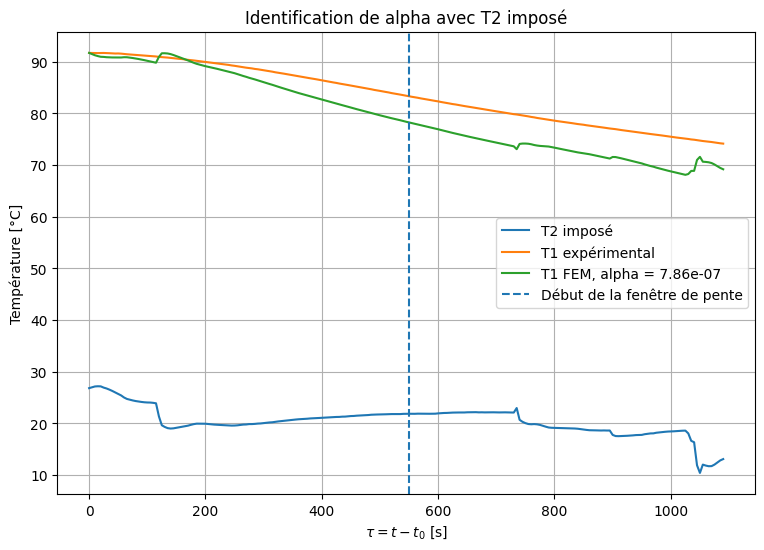

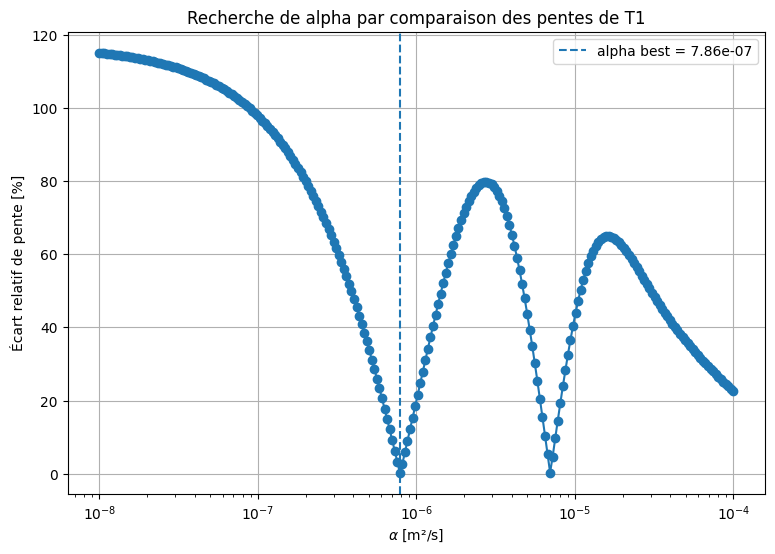

In [ ]:
# ============================================================
# VISUALISATION FINALE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(tau_ice, T2_ice_bc, label="T2 imposé")
plt.plot(tau_ice, T1_ice_exp, label="T1 expérimental")
plt.plot(
    tau_ice,
    T1_fem_best,
    label=f"T1 FEM, alpha = {alpha_best:.2e}"
)

plt.axvline(
    tau_fit_ice[0],
    linestyle="--",
    label="Début de la fenêtre de pente"
)

plt.xlabel(r"$\tau = t-t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Identification de alpha avec T2 imposé")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(9, 6))

plt.semilogx(
    df_alpha_search["alpha"],
    100.0 * df_alpha_search["relative_slope_error"],
    marker="o"
)

plt.axvline(
    alpha_best,
    linestyle="--",
    label=f"alpha best = {alpha_best:.2e}"
)

plt.xlabel(r"$\alpha$ [m²/s]")
plt.ylabel("Écart relatif de pente [%]")
plt.title("Recherche de alpha par comparaison des pentes de T1")
plt.grid(True)
plt.legend()
plt.show()

## Assemblage éléments finis avec plusieurs éléments $P_1$

Afin d’étudier l’influence du maillage, le domaine compris entre les deux capteurs est maintenant discrétisé avec plusieurs éléments finis linéaires $P_1$.

Le domaine physique est :

$$
x\in[0,L]
$$

avec :

$$
x=0
$$

du côté du capteur $T_1$, et :

$$
x=L
$$

du côté du capteur $T_2$.

Le maillage est défini par les nœuds :

$$
0=x_0<x_1<\dots<x_N=L
$$

et chaque élément est donné par :

$$
\Omega^e=[x_i,x_j]
$$

avec une longueur :

$$
h^e=x_j-x_i
$$

Sur chaque élément, on utilise les fonctions de forme linéaires classiques sur l’élément de référence :

$$
\xi\in[-1,1]
$$

avec :

$$
N_1(\xi)=\frac{1-\xi}{2}
$$

et :

$$
N_2(\xi)=\frac{1+\xi}{2}
$$

Le changement de variable est :

$$
x(\xi)
=
\frac{h^e}{2}\xi
+
\frac{x_i+x_j}{2}
$$

d’où :

$$
J^e=\frac{dx}{d\xi}=\frac{h^e}{2}
$$

et :

$$
\frac{dN}{dx}
=
\frac{1}{J^e}
\frac{dN}{d\xi}
$$

L’équation thermique utilisée est :

$$
\frac{\partial T}{\partial t}
=
\alpha
\frac{\partial^2 T}{\partial x^2}
-
s_{\mathrm{loss,no\ ice}}
$$

La forme semi-discrète obtenue par éléments finis est :

$$
M\dot{T}+\alpha KT=F
$$

avec :

$$
M_{lm}
=
\int_0^L
N_lN_m\,dx
$$

$$
K_{lm}
=
\int_0^L
\frac{dN_l}{dx}
\frac{dN_m}{dx}
\,dx
$$

et :

$$
F_l
=
-s_{\mathrm{loss,no\ ice}}
\int_0^L
N_l(x)\,dx
$$

Dans le code, les matrices globales $M$ et $K$ ainsi que le vecteur $F$ sont assemblés élément par élément à partir des contributions locales.

In [ ]:
# ============================================================
# ASSEMBLAGE FEM 1D P1 POUR PLUSIEURS ÉLÉMENTS
# ============================================================

def assemble_fem_1d_p1(x_nodes, s_loss):
    """
    Assemble M, K et F pour un maillage 1D P1.

    Équation :
        dT/dt = alpha d²T/dx² - s_loss

    Forme semi-discrète :
        M dT/dt + alpha K T = F
    """

    x_nodes = np.asarray(x_nodes, dtype=float)

    n_nodes = len(x_nodes)
    n_elements = n_nodes - 1

    M = np.zeros((n_nodes, n_nodes))
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    for e in range(n_elements):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        h_e = x_right - x_left
        J = h_e / 2.0

        local_nodes = [e, e + 1]

        M_e = np.zeros((2, 2))
        K_e = np.zeros((2, 2))
        F_e = np.zeros(2)

        for xi, w in zip(gauss_points, gauss_weights):

            N, dN_dxi = lagrange_p1(xi)

            dN_dx = dN_dxi / J

            M_e += w * np.outer(N, N) * J
            K_e += w * np.outer(dN_dx, dN_dx) * J
            F_e += w * (-s_loss * N) * J

        for i_local in range(2):
            i_global = local_nodes[i_local]

            F[i_global] += F_e[i_local]

            for j_local in range(2):
                j_global = local_nodes[j_local]
                M[i_global, j_global] += M_e[i_local, j_local]
                K[i_global, j_global] += K_e[i_local, j_local]

    return M, K, F

## Simulation transitoire avec plusieurs éléments

Une fois les matrices globales assemblées, on résout le problème transitoire :

$$
M\dot{T}+\alpha KT=F
$$

Dans cette formulation, la température mesurée par le capteur $T_2$ est imposée comme condition aux limites :

$$
T(L,t)=T_2^{\mathrm{exp}}(t)
$$

Le nœud situé en $x=L$ est donc un degré de liberté de Dirichlet :

$$
T_d(t)=T_2^{\mathrm{exp}}(t)
$$

Tous les autres nœuds sont libres. Le modèle calcule en particulier la température au nœud $x=0$ :

$$
T(0,t)=T_1^{\mathrm{FEM}}(t)
$$

Cette température sera ensuite comparée à la mesure expérimentale :

$$
T_1^{\mathrm{exp}}(t)
$$

La condition initiale imposée dans tout l’échantillon est uniforme :

$$
T(x,0)=T_1^{\mathrm{exp}}(t_0)
$$

Ainsi, au début de la simulation, tous les nœuds libres sont initialisés avec la même valeur :

$$
T_f(0)=T_1^{\mathrm{exp}}(t_0)
$$

Le système est partitionné entre degrés de liberté libres et imposés :

$$
T=
\begin{bmatrix}
T_f\\
T_d
\end{bmatrix}
$$

L’équation associée aux degrés de liberté libres est :

$$
M_{ff}\dot{T}_f
=
F_f
-
M_{fd}\dot{T}_d
-
\alpha
\left(
K_{ff}T_f+K_{fd}T_d
\right)
$$

Comme la condition aux limites $T_d(t)=T_2^{\mathrm{exp}}(t)$ dépend du temps, le terme $M_{fd}\dot{T}_d$ doit être conservé.

Pour améliorer la stabilité numérique lorsque le maillage est raffiné, l’intégration temporelle est réalisée ici avec un schéma implicite :

$$
\left(
\frac{M_{ff}}{\Delta t}
+
\alpha K_{ff}
\right)
T_f^{n+1}
=
\frac{M_{ff}}{\Delta t}T_f^n
+
F_f
-
M_{fd}\dot{T}_d^n
-
\alpha K_{fd}T_d^{n+1}
$$

Ce schéma permet de calculer l’évolution temporelle de tous les nœuds libres du maillage, et en particulier :

$$
T_1^{\mathrm{FEM}}(t)=T_f(t)\big|_{x=0}
$$

In [ ]:
# ============================================================
# SIMULATION FEM AVEC PLUSIEURS ÉLÉMENTS
# ============================================================

def simulate_T1_for_alpha_mesh(
    alpha,
    tau,
    T1_exp,
    T2_bc,
    x_nodes,
    M,
    K,
    F,
    times_to_save=None
):
    """
    Résout le problème avec plusieurs éléments P1.

    Domaine :
        x = 0      -> T1_FEM calculé
        x = L      -> T2_exp imposé

    Condition initiale :
        T(x,0) = T1_exp(t0)
        pour tous les nœuds libres.

    Condition aux limites :
        T(L,t) = T2_exp(t)
    """

    alpha = float(alpha)

    tau = np.asarray(tau, dtype=float)
    T1_exp = np.asarray(T1_exp, dtype=float)
    T2_bc = np.asarray(T2_bc, dtype=float)

    n_nodes = len(x_nodes)

    # Nœud imposé : dernier nœud, correspondant à T2
    dirichlet_nodes = np.array([n_nodes - 1], dtype=int)

    # Tous les autres nœuds sont libres
    free_nodes = np.arange(n_nodes - 1)

    M_ff = M[np.ix_(free_nodes, free_nodes)]
    M_fd = M[np.ix_(free_nodes, dirichlet_nodes)]

    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    F_f = F[free_nodes]

    # Condition initiale :
    # température uniforme égale à T1(t0) dans l'échantillon
    T_f = np.full(len(free_nodes), T1_exp[0], dtype=float)

    T1_fem = np.zeros_like(T1_exp, dtype=float)
    T1_fem[0] = T_f[0]

    saved_profiles = {}

    if times_to_save is None:
        times_to_save = [tau[0], tau[-1]]

    save_indices = [
        int(np.argmin(np.abs(tau - time_value)))
        for time_value in times_to_save
    ]

    save_indices = sorted(set(save_indices))

    def build_full_temperature(T_f_current, T2_current):
        T_full = np.zeros(n_nodes)
        T_full[free_nodes] = T_f_current
        T_full[dirichlet_nodes] = T2_current
        return T_full

    if 0 in save_indices:
        saved_profiles[0] = build_full_temperature(T_f, T2_bc[0])

    for n in range(len(tau) - 1):

        dt_n = tau[n + 1] - tau[n]

        T_d_n = np.array([T2_bc[n]])
        T_d_np1 = np.array([T2_bc[n + 1]])

        dT_d = (T_d_np1 - T_d_n) / dt_n

        # Euler implicite pour stabilité lorsque le maillage est raffiné :
        #
        # (M_ff/dt + alpha K_ff) T_f^{n+1}
        # =
        # M_ff T_f^n/dt
        # + F_f
        # - M_fd dT_d/dt
        # - alpha K_fd T_d^{n+1}

        A = M_ff / dt_n + alpha * K_ff

        b = (
            M_ff @ T_f / dt_n
            + F_f
            - M_fd @ dT_d
            - alpha * (K_fd @ T_d_np1)
        )

        T_f = np.linalg.solve(A, b)

        T1_fem[n + 1] = T_f[0]

        if (n + 1) in save_indices:
            saved_profiles[n + 1] = build_full_temperature(T_f, T2_bc[n + 1])

    return T1_fem, saved_profiles

## Identification de $\alpha$ pour un maillage donné

Pour un nombre fixé d’éléments $N_e$, on construit d’abord le maillage :

$$
x_0,x_1,\dots,x_N
$$

puis on assemble les matrices globales :

$$
M,\quad K,\quad F
$$

Pour chaque valeur candidate de la diffusivité thermique $\alpha$, le modèle calcule une évolution temporelle :

$$
T_1^{\mathrm{FEM}}(t;\alpha)
$$

Cette courbe est comparée à la température expérimentale :

$$
T_1^{\mathrm{exp}}(t)
$$

Conformément au critère retenu, la comparaison ne se fait pas sur toute la forme de la courbe, mais uniquement sur la pente de la partie la plus linéaire. Dans cette première approche, on utilise la partie droite de la courbe :

$$
\tau\in
\left[
\eta \tau_{\max},
\tau_{\max}
\right]
$$

avec, par exemple :

$$
\eta=0.5
$$

ce qui correspond à la moitié droite de la courbe.

On ajuste alors :

$$
T_1^{\mathrm{exp}}(\tau)
\simeq
b_0^{\mathrm{exp}}
+
b_1^{\mathrm{exp}}\tau
$$

et :

$$
T_1^{\mathrm{FEM}}(\tau;\alpha)
\simeq
b_0^{\mathrm{FEM}}(\alpha)
+
b_1^{\mathrm{FEM}}(\alpha)\tau
$$

L’erreur utilisée pour identifier $\alpha$ est l’écart relatif entre les pentes :

$$
\varepsilon_{\mathrm{pente}}(\alpha)
=
\frac{
\left|
b_1^{\mathrm{FEM}}(\alpha)
-
b_1^{\mathrm{exp}}
\right|
}{
\left|
b_1^{\mathrm{exp}}
\right|
}
$$

La diffusivité retenue pour ce maillage est donc :

$$
\alpha^\star(N_e)
=
\operatorname*{arg\,min}_{\alpha}
\varepsilon_{\mathrm{pente}}(\alpha)
$$

Cette procédure est répétée indépendamment pour chaque nombre d’éléments.

In [ ]:
# ============================================================
# IDENTIFICATION DE ALPHA POUR UN MAILLAGE DONNÉ
# ============================================================

def identify_alpha_for_mesh(N_elements, times_to_save=None):
    """
    Identifie alpha pour un maillage de N_elements éléments.

    Le critère est l'écart relatif entre les pentes de :
        T1_exp
        T1_FEM
    """

    x_nodes = np.linspace(0.0, L_ice, N_elements + 1)

    M_mesh, K_mesh, F_mesh = assemble_fem_1d_p1(
        x_nodes=x_nodes,
        s_loss=s_loss_no_ice
    )

    slope_T1_exp = linear_slope(
    tau_ice,
    T1_ice_exp,
    start_fraction=fit_start_fraction_ice
)
    results_alpha = []

    best_T1_fem = None
    best_profiles = None

    for alpha_value in alpha_values:

        T1_fem_alpha, saved_profiles_alpha = simulate_T1_for_alpha_mesh(
            alpha=alpha_value,
            tau=tau_ice,
            T1_exp=T1_ice_exp,
            T2_bc=T2_ice_bc,
            x_nodes=x_nodes,
            M=M_mesh,
            K=K_mesh,
            F=F_mesh,
            times_to_save=times_to_save
        )

        slope_T1_fem = linear_slope(
        tau_ice,
        T1_fem_alpha,
        start_fraction=fit_start_fraction_ice
        )

        abs_slope_error = abs(slope_T1_fem - slope_T1_exp)

        relative_slope_error = abs_slope_error / max(abs(slope_T1_exp), 1e-15)

        results_alpha.append({
            "N_elements": N_elements,
            "N_nodes": N_elements + 1,
            "alpha": alpha_value,
            "slope_T1_exp": slope_T1_exp,
            "slope_T1_fem": slope_T1_fem,
            "abs_slope_error": abs_slope_error,
            "relative_slope_error": relative_slope_error
        })

    df_alpha_mesh = pd.DataFrame(results_alpha)

    idx_best = df_alpha_mesh["relative_slope_error"].idxmin()

    alpha_best_mesh = df_alpha_mesh.loc[idx_best, "alpha"]

    T1_fem_best_mesh, saved_profiles_best_mesh = simulate_T1_for_alpha_mesh(
        alpha=alpha_best_mesh,
        tau=tau_ice,
        T1_exp=T1_ice_exp,
        T2_bc=T2_ice_bc,
        x_nodes=x_nodes,
        M=M_mesh,
        K=K_mesh,
        F=F_mesh,
        times_to_save=times_to_save
    )

    row_best = df_alpha_mesh.loc[idx_best].copy()

    return {
        "N_elements": N_elements,
        "N_nodes": N_elements + 1,
        "x_nodes": x_nodes,
        "M": M_mesh,
        "K": K_mesh,
        "F": F_mesh,
        "df_alpha": df_alpha_mesh,
        "best_row": row_best,
        "alpha_best": alpha_best_mesh,
        "T1_fem_best": T1_fem_best_mesh,
        "saved_profiles": saved_profiles_best_mesh
    }

## Étude de convergence en maillage

L’objectif de cette étape est de vérifier si l’utilisation d’un seul élément fini est suffisante ou si le résultat dépend fortement du nombre d’éléments.

On répète donc l’identification de la diffusivité thermique pour plusieurs maillages :

$$
N_e=1,2,4,8,16,32
$$

Pour chaque maillage, on obtient une valeur identifiée :

$$
\alpha^\star(N_e)
$$

ainsi qu’un écart relatif de pente :

$$
\varepsilon_{\mathrm{pente}}(N_e)
$$

Si le modèle est convergé en maillage, alors l’augmentation du nombre d’éléments ne doit plus modifier significativement la valeur identifiée de $\alpha$ :

$$
\alpha^\star(N_e)
\longrightarrow
\alpha^\star
$$

lorsque :

$$
N_e\rightarrow\infty
$$

De même, l’écart relatif de pente doit se stabiliser lorsque le maillage devient plus fin.

Cette étude permet donc de vérifier si le modèle à un seul élément est suffisamment robuste ou si plusieurs éléments sont nécessaires pour représenter correctement le profil thermique dans l’échantillon.

In [ ]:
# ============================================================
# ÉTUDE DE CONVERGENCE EN MAILLAGE
# ============================================================

N_elements_values = [1, 2, 4, 8, 16, 32]

times_to_save_convergence = [
    tau_ice[0],
    0.25 * tau_ice[-1],
    0.50 * tau_ice[-1],
    tau_ice[-1]
]

mesh_results = []

summary_rows = []

for N_elements in N_elements_values:

    result_mesh = identify_alpha_for_mesh(
        N_elements=N_elements,
        times_to_save=times_to_save_convergence
    )

    mesh_results.append(result_mesh)

    best_row = result_mesh["best_row"]

    summary_rows.append({
        "N_elements": result_mesh["N_elements"],
        "N_nodes": result_mesh["N_nodes"],
        "alpha_best": result_mesh["alpha_best"],
        "slope_T1_exp": best_row["slope_T1_exp"],
        "slope_T1_fem": best_row["slope_T1_fem"],
        "relative_slope_error_percent": 100.0 * best_row["relative_slope_error"]
    })

df_mesh_convergence = pd.DataFrame(summary_rows)

display(df_mesh_convergence)

print("Étude de convergence terminée.")

,N_elements,N_nodes,alpha_best,slope_T1_exp,slope_T1_fem,relative_slope_error_percent
0,1,2,7.862892e-07,-0.016834,-0.016796,0.225713
1,2,3,6.069215e-07,-0.016834,-0.017126,1.734893
2,4,5,7.577363e-07,-0.016834,-0.016430,2.399413
3,8,9,1.127740e-05,-0.016834,-0.016812,0.127422
4,16,17,1.127740e-05,-0.016834,-0.016924,0.532930
5,32,33,1.127740e-05,-0.016834,-0.016951,0.698319


Étude de convergence terminée.


## Convergence de la diffusivité identifiée

On représente maintenant la valeur identifiée de la diffusivité thermique en fonction du nombre d’éléments :

$$
\alpha^\star=\alpha^\star(N_e)
$$

Cette courbe permet d’évaluer la sensibilité du résultat au raffinement du maillage.

Si les valeurs de $\alpha^\star$ varient fortement lorsque $N_e$ augmente, cela signifie que le modèle avec un seul élément n’est pas suffisant pour identifier une valeur stable.

Au contraire, si les valeurs se stabilisent à partir d’un certain nombre d’éléments, on peut considérer que l’identification est convergée en maillage.

On trace également l’écart relatif entre les pentes :

$$
\varepsilon_{\mathrm{pente}}(N_e)
$$

afin de vérifier que la qualité de l’identification reste cohérente lorsque le maillage est raffiné.

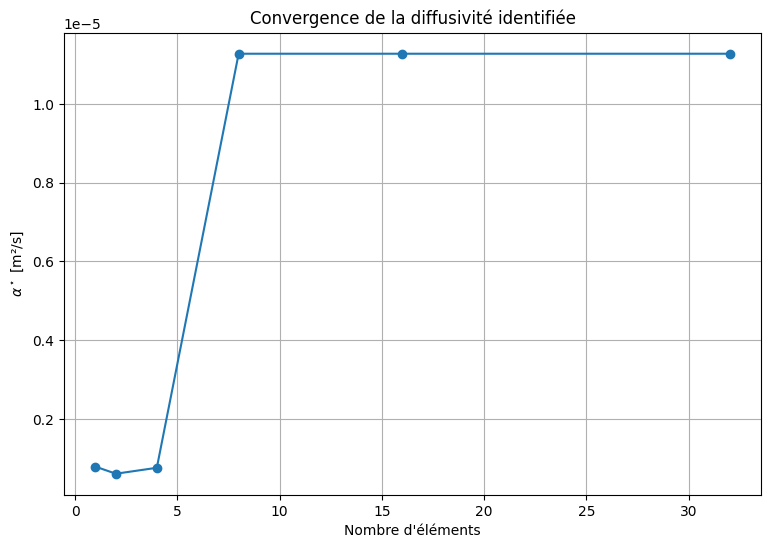

In [ ]:
# ============================================================
# CONVERGENCE DE ALPHA EN FONCTION DU MAILLAGE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence["N_elements"],
    df_mesh_convergence["alpha_best"],
    marker="o"
)

plt.xlabel("Nombre d'éléments")
plt.ylabel(r"$\alpha^\star$ [m²/s]")
plt.title("Convergence de la diffusivité identifiée")
plt.grid(True)
plt.show()




## Profils spatiaux de température pour différents maillages

L’étude de convergence ne porte pas seulement sur la valeur de $\alpha$. Il est également utile d’observer le profil spatial de température calculé dans l’échantillon.

Pour un instant donné $\tau$, le modèle fournit une approximation du champ thermique :

$$
T^{\mathrm{FEM}}(x,\tau)
$$

On trace ce profil pour plusieurs nombres d’éléments afin de visualiser l’influence du maillage sur la distribution spatiale de température.

Le bord droit du domaine est imposé par la mesure expérimentale :

$$
T(L,t)=T_2^{\mathrm{exp}}(t)
$$

tandis que le bord gauche est calculé par le modèle :

$$
T(0,t)=T_1^{\mathrm{FEM}}(t)
$$

Si les profils spatiaux obtenus avec différents maillages deviennent proches les uns des autres, cela indique que la solution spatiale est peu sensible au raffinement du maillage.

Cette représentation permet donc de vérifier directement si le nombre d’éléments utilisé est suffisant pour décrire l’évolution de la température dans l’échantillon.

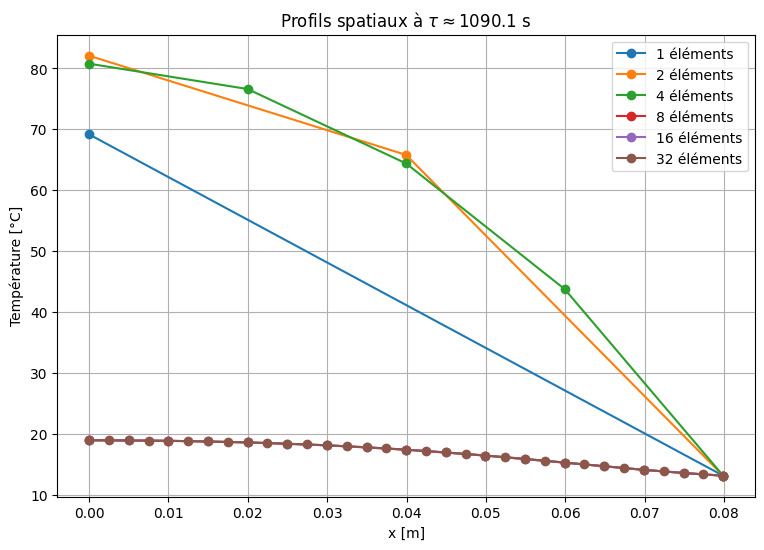

In [ ]:
# ============================================================
# PROFILS SPATIAUX POUR DIFFÉRENTS MAILLAGES
# ============================================================

# On choisit le dernier instant sauvegardé
target_time = tau_ice[-1]

plt.figure(figsize=(9, 6))

for result_mesh in mesh_results:

    x_nodes = result_mesh["x_nodes"]
    saved_profiles = result_mesh["saved_profiles"]

    # Chercher l'indice sauvegardé le plus proche de target_time
    saved_indices = list(saved_profiles.keys())
    saved_times = np.array([tau_ice[idx] for idx in saved_indices])

    idx_closest_local = int(np.argmin(np.abs(saved_times - target_time)))
    saved_index = saved_indices[idx_closest_local]

    T_profile = saved_profiles[saved_index]

    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"{result_mesh['N_elements']} éléments"
    )

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title(rf"Profils spatiaux à $\tau \approx {target_time:.1f}$ s")
plt.grid(True)
plt.legend()
plt.show()

## Influence du maillage sur l’évolution de $T_1^{\mathrm{FEM}}$

On compare finalement l’évolution temporelle de la température calculée au niveau du capteur $T_1$ pour différents maillages.

Pour chaque nombre d’éléments, le modèle calcule :

$$
T_1^{\mathrm{FEM}}(t;N_e)
$$

Cette courbe est comparée à la mesure expérimentale :

$$
T_1^{\mathrm{exp}}(t)
$$

La condition aux limites reste la même pour tous les maillages :

$$
T(L,t)=T_2^{\mathrm{exp}}(t)
$$

et la condition initiale est toujours uniforme :

$$
T(x,0)=T_1^{\mathrm{exp}}(t_0)
$$

Cette comparaison permet de voir si le signal calculé au capteur $T_1$ dépend fortement du nombre d’éléments.

Si les courbes $T_1^{\mathrm{FEM}}(t;N_e)$ se superposent lorsque $N_e$ augmente, alors le modèle est convergé pour la grandeur utilisée dans l’identification de $\alpha$.

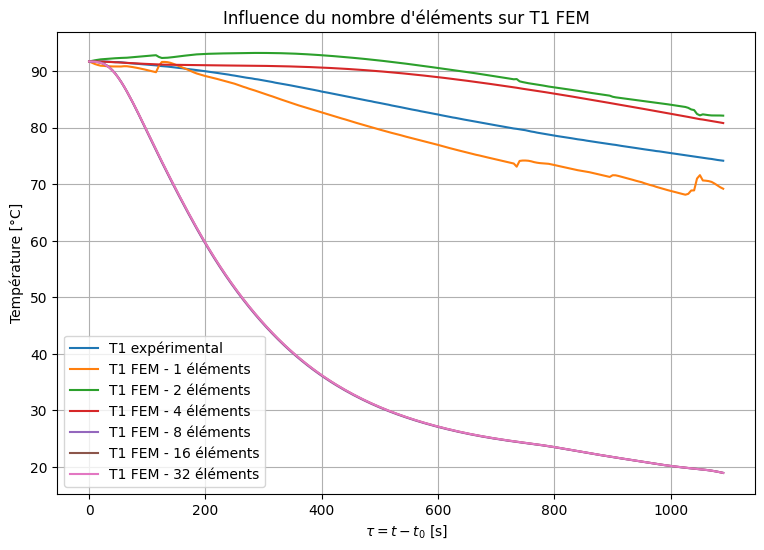

In [ ]:
# ============================================================
# ÉVOLUTION DE T1_FEM POUR DIFFÉRENTS MAILLAGES
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice,
    T1_ice_exp,
    label="T1 expérimental"
)

for result_mesh in mesh_results:

    plt.plot(
        tau_ice,
        result_mesh["T1_fem_best"],
        label=f"T1 FEM - {result_mesh['N_elements']} éléments"
    )

plt.xlabel(r"$\tau = t-t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Influence du nombre d'éléments sur T1 FEM")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# ÉTUDE DE CONVERGENCE EN MAILLAGE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PARAMÈTRES MODIFIABLES POUR L'ÉTUDE DE CONVERGENCE
# ============================================================

# Nombre de nœuds à tester.
# N_elements = N_nodes - 1
#
# Exemple :
# 2 nœuds  -> 1 élément
# 3 nœuds  -> 2 éléments
# 5 nœuds  -> 4 éléments
# 9 nœuds  -> 8 éléments
# 17 nœuds -> 16 éléments
# 33 nœuds -> 32 éléments

N_nodes_values_extra = [2, 3, 5, 9, 17, 33, 65]

# Fenêtre de calcul de pente.
# 0.5 = on utilise la moitié droite de la courbe.
fit_start_fraction_mesh_extra = 0.5

# Recherche de alpha.
# Pour l'acier, alpha attendu ~ 1e-5 m²/s.
alpha_min_mesh_extra = 1.0e-10
alpha_max_mesh_extra = 1.0e-3
n_alpha_mesh_extra = 500

alpha_values_mesh_extra = np.logspace(
    np.log10(alpha_min_mesh_extra),
    np.log10(alpha_max_mesh_extra),
    n_alpha_mesh_extra
)

# Valeurs de référence pour un acier doux / acier bas carbone.
rho_steel_extra = 7850.0        # [kg/m3]
cp_steel_extra = 470.0          # [J/(kg K)]
lambda_steel_extra = 50.0       # [W/(m K)]

alpha_steel_ref_extra = lambda_steel_extra / (rho_steel_extra * cp_steel_extra)

print("Paramètres de l'étude de convergence :")
print(f"N_nodes_values_extra = {N_nodes_values_extra}")
print(f"alpha_min = {alpha_min_mesh_extra:.3e} m²/s")
print(f"alpha_max = {alpha_max_mesh_extra:.3e} m²/s")
print(f"n_alpha = {n_alpha_mesh_extra}")
print(f"fenêtre de pente = dernière fraction {1.0 - fit_start_fraction_mesh_extra:.2f} de la courbe")
print()
print("Référence acier :")
print(f"rho = {rho_steel_extra:.3e} kg/m3")
print(f"cp = {cp_steel_extra:.3e} J/(kg K)")
print(f"lambda = {lambda_steel_extra:.3e} W/(m K)")
print(f"alpha_ref = {alpha_steel_ref_extra:.3e} m²/s")

Paramètres de l'étude de convergence :
N_nodes_values_extra = [2, 3, 5, 9, 17, 33, 65]
alpha_min = 1.000e-10 m²/s
alpha_max = 1.000e-03 m²/s
n_alpha = 500
fenêtre de pente = dernière fraction 0.50 de la courbe

Référence acier :
rho = 7.850e+03 kg/m3
cp = 4.700e+02 J/(kg K)
lambda = 5.000e+01 W/(m K)
alpha_ref = 1.355e-05 m²/s


In [ ]:
# ============================================================
# FONCTIONS SUPPLÉMENTAIRES
# ============================================================

def extract_right_part_extra(t, y, start_fraction=0.5):
    """
    Extrait la partie droite d'une courbe pour calculer une pente.

    start_fraction = 0.5 signifie que l'on garde la moitié droite.
    """

    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    t_start = t[0] + start_fraction * (t[-1] - t[0])

    mask = t >= t_start

    if np.sum(mask) < 2:
        raise ValueError("Pas assez de points pour calculer la pente.")

    return t[mask], y[mask], mask


def linear_slope_extra(t, y, start_fraction=0.5):
    """
    Calcule la pente d'un ajustement linéaire sur la partie droite.
    """

    t_fit, y_fit, mask = extract_right_part_extra(
        t,
        y,
        start_fraction=start_fraction
    )

    b1, b0 = np.polyfit(t_fit, y_fit, deg=1)

    return b1


def assemble_fem_1d_p1_extra(x_nodes, s_loss):
    """
    Assemble les matrices globales M, K et F pour un maillage 1D P1.

    Équation :
        dT/dt = alpha d²T/dx² - s_loss

    Forme semi-discrète :
        M dT/dt + alpha K T = F
    """

    x_nodes = np.asarray(x_nodes, dtype=float)

    n_nodes = len(x_nodes)
    n_elements = n_nodes - 1

    M = np.zeros((n_nodes, n_nodes))
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    for e in range(n_elements):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        h_e = x_right - x_left
        J = h_e / 2.0

        local_nodes = [e, e + 1]

        M_e = np.zeros((2, 2))
        K_e = np.zeros((2, 2))
        F_e = np.zeros(2)

        for xi, w in zip(gauss_points, gauss_weights):

            N, dN_dxi = lagrange_p1(xi)

            N = np.asarray(N, dtype=float)
            dN_dxi = np.asarray(dN_dxi, dtype=float)

            dN_dx = dN_dxi / J

            M_e += w * np.outer(N, N) * J
            K_e += w * np.outer(dN_dx, dN_dx) * J
            F_e += w * (-s_loss * N) * J

        for i_local in range(2):

            i_global = local_nodes[i_local]

            F[i_global] += F_e[i_local]

            for j_local in range(2):

                j_global = local_nodes[j_local]

                M[i_global, j_global] += M_e[i_local, j_local]
                K[i_global, j_global] += K_e[i_local, j_local]

    return M, K, F


def simulate_T1_for_alpha_mesh_extra(
    alpha,
    tau,
    T1_exp,
    T2_bc,
    x_nodes,
    M,
    K,
    F,
    times_to_save=None
):
    """
    Simulation FEM transitoire avec plusieurs éléments.

    Domaine :
        x = 0  -> T1_FEM calculé
        x = L  -> T2_exp imposé

    Condition initiale :
        T(x,0) = T1_exp(t0)
        sur tous les nœuds libres.

    Condition aux limites :
        T(L,t) = T2_exp(t)
    """

    alpha = float(alpha)

    tau = np.asarray(tau, dtype=float)
    T1_exp = np.asarray(T1_exp, dtype=float)
    T2_bc = np.asarray(T2_bc, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)

    n_nodes = len(x_nodes)

    # Dernier nœud imposé : T2 expérimental
    dirichlet_nodes = np.array([n_nodes - 1], dtype=int)

    # Tous les autres nœuds sont libres
    free_nodes = np.arange(n_nodes - 1)

    M_ff = M[np.ix_(free_nodes, free_nodes)]
    M_fd = M[np.ix_(free_nodes, dirichlet_nodes)]

    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    F_f = F[free_nodes]

    # Condition initiale uniforme :
    # tout l'échantillon commence à T1_exp(t0), sauf le nœud imposé.
    T_f = np.full(len(free_nodes), T1_exp[0], dtype=float)

    T1_fem = np.zeros_like(T1_exp, dtype=float)
    T1_fem[0] = T_f[0]

    saved_profiles = {}

    if times_to_save is None:
        times_to_save = [tau[0], tau[-1]]

    save_indices = [
        int(np.argmin(np.abs(tau - time_value)))
        for time_value in times_to_save
    ]

    save_indices = sorted(set(save_indices))

    def build_full_temperature(T_f_current, T2_current):
        T_full = np.zeros(n_nodes)
        T_full[free_nodes] = T_f_current
        T_full[dirichlet_nodes] = T2_current
        return T_full

    if 0 in save_indices:
        saved_profiles[0] = build_full_temperature(T_f, T2_bc[0])

    for n in range(len(tau) - 1):

        dt_n = tau[n + 1] - tau[n]

        if dt_n <= 0:
            raise ValueError("Le vecteur temps tau doit être strictement croissant.")

        T_d_n = np.array([T2_bc[n]])
        T_d_np1 = np.array([T2_bc[n + 1]])

        dT_d = (T_d_np1 - T_d_n) / dt_n

        # Schéma implicite :
        #
        # (M_ff/dt + alpha K_ff) T_f^{n+1}
        # =
        # M_ff T_f^n/dt
        # + F_f
        # - M_fd dT_d/dt
        # - alpha K_fd T_d^{n+1}

        A = M_ff / dt_n + alpha * K_ff

        b = (
            M_ff @ T_f / dt_n
            + F_f
            - M_fd @ dT_d
            - alpha * (K_fd @ T_d_np1)
        )

        T_f = np.linalg.solve(A, b)

        T1_fem[n + 1] = T_f[0]

        if (n + 1) in save_indices:
            saved_profiles[n + 1] = build_full_temperature(T_f, T2_bc[n + 1])

    return T1_fem, saved_profiles

In [ ]:
# ============================================================
# IDENTIFICATION DE ALPHA POUR UN NOMBRE DONNÉ DE NŒUDS
# ============================================================

def identify_alpha_for_n_nodes_extra(
    N_nodes,
    alpha_values_to_test=None,
    times_to_save=None,
    verbose=True
):
    """
    Identifie alpha pour un maillage défini par N_nodes.

    Le critère est l'écart relatif entre les pentes de :
        T1_exp
        T1_FEM

    Les pentes sont calculées uniquement sur la partie droite de la courbe.
    """

    if N_nodes < 2:
        raise ValueError("Il faut au moins 2 nœuds.")

    if alpha_values_to_test is None:
        alpha_values_to_test = alpha_values_mesh_extra

    N_elements = N_nodes - 1

    x_nodes = np.linspace(0.0, L_ice, N_nodes)

    M_mesh, K_mesh, F_mesh = assemble_fem_1d_p1_extra(
        x_nodes=x_nodes,
        s_loss=s_loss_no_ice
    )

    slope_T1_exp = linear_slope_extra(
        tau_ice,
        T1_ice_exp,
        start_fraction=fit_start_fraction_mesh_extra
    )

    results_alpha = []

    for alpha_value in alpha_values_to_test:

        T1_fem_alpha, saved_profiles_alpha = simulate_T1_for_alpha_mesh_extra(
            alpha=alpha_value,
            tau=tau_ice,
            T1_exp=T1_ice_exp,
            T2_bc=T2_ice_bc,
            x_nodes=x_nodes,
            M=M_mesh,
            K=K_mesh,
            F=F_mesh,
            times_to_save=times_to_save
        )

        slope_T1_fem = linear_slope_extra(
            tau_ice,
            T1_fem_alpha,
            start_fraction=fit_start_fraction_mesh_extra
        )

        abs_slope_error = abs(slope_T1_fem - slope_T1_exp)

        relative_slope_error = abs_slope_error / max(abs(slope_T1_exp), 1e-15)

        results_alpha.append({
            "N_nodes": N_nodes,
            "N_elements": N_elements,
            "alpha": alpha_value,
            "slope_T1_exp": slope_T1_exp,
            "slope_T1_fem": slope_T1_fem,
            "abs_slope_error": abs_slope_error,
            "relative_slope_error": relative_slope_error
        })

    df_alpha_mesh = pd.DataFrame(results_alpha)

    idx_best = df_alpha_mesh["relative_slope_error"].idxmin()

    alpha_best_mesh = df_alpha_mesh.loc[idx_best, "alpha"]
    best_row = df_alpha_mesh.loc[idx_best].copy()

    T1_fem_best_mesh, saved_profiles_best_mesh = simulate_T1_for_alpha_mesh_extra(
        alpha=alpha_best_mesh,
        tau=tau_ice,
        T1_exp=T1_ice_exp,
        T2_bc=T2_ice_bc,
        x_nodes=x_nodes,
        M=M_mesh,
        K=K_mesh,
        F=F_mesh,
        times_to_save=times_to_save
    )

    boundary_status = "inside"

    if alpha_best_mesh == alpha_values_to_test[0]:
        boundary_status = "lower_bound"

    if alpha_best_mesh == alpha_values_to_test[-1]:
        boundary_status = "upper_bound"

    if verbose:
        print()
        print("Résultat pour le maillage :")
        print(f"N_nodes = {N_nodes}")
        print(f"N_elements = {N_elements}")
        print(f"alpha_best = {alpha_best_mesh:.6e} m²/s")
        print(f"alpha_best / alpha_steel_ref = {alpha_best_mesh / alpha_steel_ref_extra:.6e}")
        print(f"pente T1 exp = {best_row['slope_T1_exp']:.6e} °C/s")
        print(f"pente T1 FEM = {best_row['slope_T1_fem']:.6e} °C/s")
        print(f"écart relatif = {100.0 * best_row['relative_slope_error']:.6f} %")
        print(f"position dans l'intervalle alpha = {boundary_status}")

    return {
        "N_nodes": N_nodes,
        "N_elements": N_elements,
        "x_nodes": x_nodes,
        "M": M_mesh,
        "K": K_mesh,
        "F": F_mesh,
        "df_alpha": df_alpha_mesh,
        "best_row": best_row,
        "alpha_best": alpha_best_mesh,
        "T1_fem_best": T1_fem_best_mesh,
        "saved_profiles": saved_profiles_best_mesh,
        "boundary_status": boundary_status
    }

In [ ]:
# ============================================================
# LANCEMENT DE L'ÉTUDE DE CONVERGENCE
# ============================================================

times_to_save_convergence_extra = [
    tau_ice[0],
    0.25 * tau_ice[-1],
    0.50 * tau_ice[-1],
    tau_ice[-1]
]

mesh_results_extra = []
summary_rows_extra = []

for N_nodes in N_nodes_values_extra:

    result_mesh = identify_alpha_for_n_nodes_extra(
        N_nodes=N_nodes,
        alpha_values_to_test=alpha_values_mesh_extra,
        times_to_save=times_to_save_convergence_extra,
        verbose=True
    )

    mesh_results_extra.append(result_mesh)

    best_row = result_mesh["best_row"]

    summary_rows_extra.append({
        "N_nodes": result_mesh["N_nodes"],
        "N_elements": result_mesh["N_elements"],
        "alpha_best": result_mesh["alpha_best"],
        "alpha_best_over_alpha_steel": result_mesh["alpha_best"] / alpha_steel_ref_extra,
        "slope_T1_exp": best_row["slope_T1_exp"],
        "slope_T1_fem": best_row["slope_T1_fem"],
        "relative_slope_error_percent": 100.0 * best_row["relative_slope_error"],
        "boundary_status": result_mesh["boundary_status"]
    })

df_mesh_convergence_extra = pd.DataFrame(summary_rows_extra)

display(df_mesh_convergence_extra)


Résultat pour le maillage :
N_nodes = 2
N_elements = 1
alpha_best = 7.939618e-07 m²/s
alpha_best / alpha_steel_ref = 5.858644e-02
pente T1 exp = -1.683385e-02 °C/s
pente T1 FEM = -1.693025e-02 °C/s
écart relatif = 0.572686 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 3
N_elements = 2
alpha_best = 5.936727e-07 m²/s
alpha_best / alpha_steel_ref = 4.380711e-02
pente T1 exp = -1.683385e-02 °C/s
pente T1 FEM = -1.672715e-02 °C/s
écart relatif = 0.633803 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 5
N_elements = 4
alpha_best = 7.687260e-07 m²/s
alpha_best / alpha_steel_ref = 5.672429e-02
pente T1 exp = -1.683385e-02 °C/s
pente T1 FEM = -1.678171e-02 °C/s
écart relatif = 0.309725 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 9
N_elements = 8
alpha_best = 1.122277e-05 m²/s
alpha_best / alpha_steel_ref = 8.281285e-01
pente T1 exp = -1.683385e-02 °C/s
pente T1 FEM = -1.693272e-02 °C

,N_nodes,N_elements,alpha_best,alpha_best_over_alpha_steel,slope_T1_exp,slope_T1_fem,relative_slope_error_percent,boundary_status
0,2,1,7.939618e-07,0.058586,-0.016834,-0.016930,0.572686,inside
1,3,2,5.936727e-07,0.043807,-0.016834,-0.016727,0.633803,inside
2,5,4,7.687260e-07,0.056724,-0.016834,-0.016782,0.309725,inside
3,9,8,1.122277e-05,0.828128,-0.016834,-0.016933,0.587339,inside
4,17,16,8.200261e-07,0.060510,-0.016834,-0.016737,0.574460,inside
5,33,32,8.200261e-07,0.060510,-0.016834,-0.016665,1.000613,inside
6,65,64,8.200261e-07,0.060510,-0.016834,-0.016648,1.105794,inside


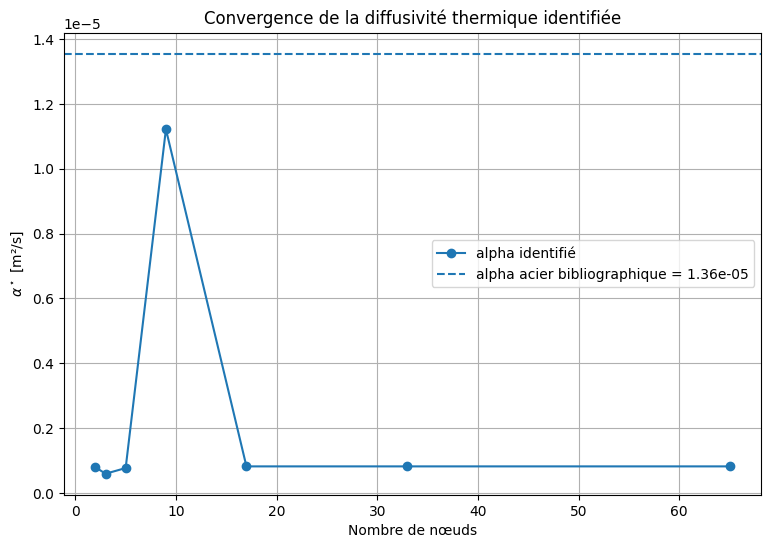

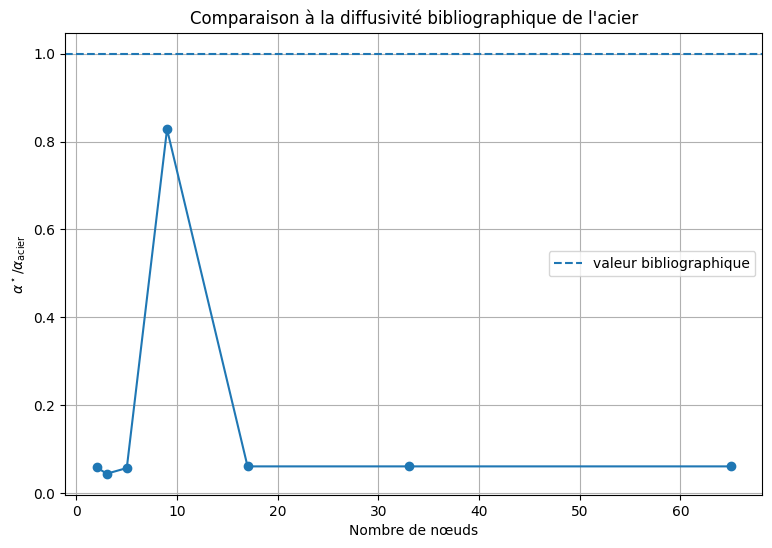

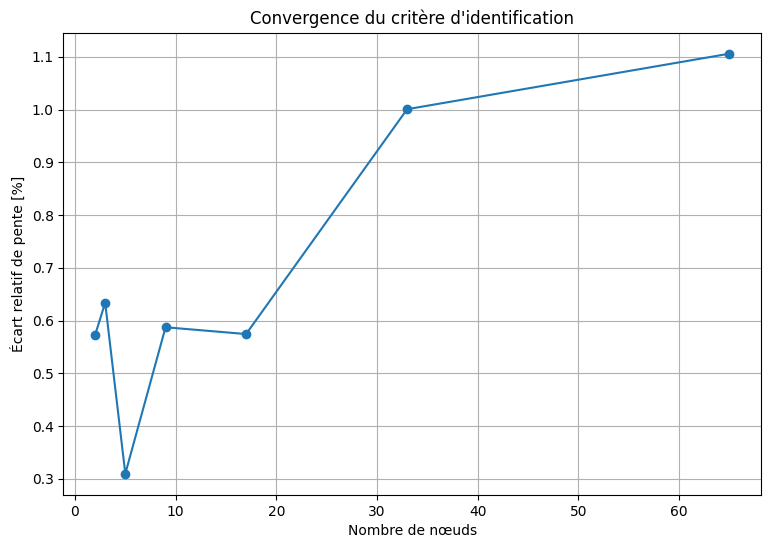

In [ ]:
# ============================================================
# GRAPHIQUE 1 : CONVERGENCE DE ALPHA
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence_extra["N_nodes"],
    df_mesh_convergence_extra["alpha_best"],
    marker="o",
    label="alpha identifié"
)

plt.axhline(
    alpha_steel_ref_extra,
    linestyle="--",
    label=f"alpha acier bibliographique = {alpha_steel_ref_extra:.2e}"
)

plt.xlabel("Nombre de nœuds")
plt.ylabel(r"$\alpha^\star$ [m²/s]")
plt.title("Convergence de la diffusivité thermique identifiée")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# GRAPHIQUE 2 : RATIO ALPHA / ALPHA ACIER
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence_extra["N_nodes"],
    df_mesh_convergence_extra["alpha_best_over_alpha_steel"],
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="valeur bibliographique"
)

plt.xlabel("Nombre de nœuds")
plt.ylabel(r"$\alpha^\star / \alpha_{\mathrm{acier}}$")
plt.title("Comparaison à la diffusivité bibliographique de l'acier")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# GRAPHIQUE 3 : ÉCART RELATIF DE PENTE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence_extra["N_nodes"],
    df_mesh_convergence_extra["relative_slope_error_percent"],
    marker="o"
)

plt.xlabel("Nombre de nœuds")
plt.ylabel("Écart relatif de pente [%]")
plt.title("Convergence du critère d'identification")
plt.grid(True)
plt.show()

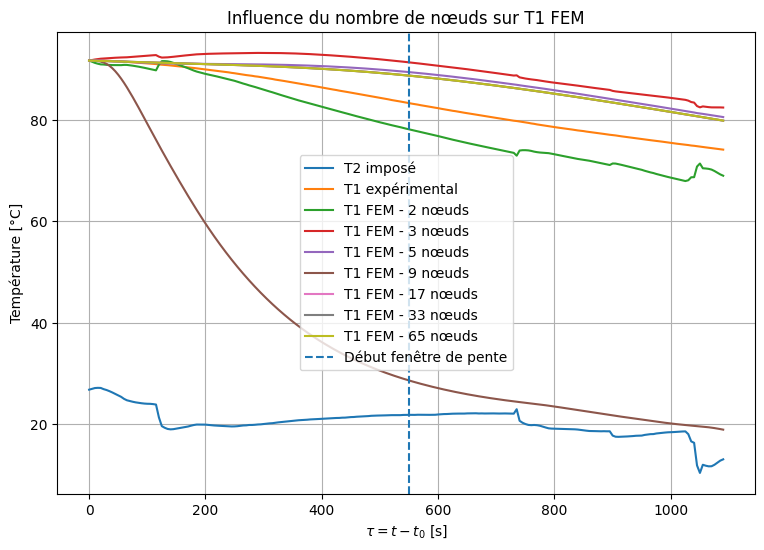

In [ ]:
# ============================================================
# GRAPHIQUE 4 : COMPARAISON DES COURBES T1_FEM
# ============================================================

tau_fit_ice_extra, T1_exp_fit_ice_extra, mask_fit_ice_extra = extract_right_part_extra(
    tau_ice,
    T1_ice_exp,
    start_fraction=fit_start_fraction_mesh_extra
)

plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice,
    T2_ice_bc,
    label="T2 imposé"
)

plt.plot(
    tau_ice,
    T1_ice_exp,
    label="T1 expérimental"
)

for result_mesh in mesh_results_extra:

    plt.plot(
        tau_ice,
        result_mesh["T1_fem_best"],
        label=f"T1 FEM - {result_mesh['N_nodes']} nœuds"
    )

plt.axvline(
    tau_fit_ice_extra[0],
    linestyle="--",
    label="Début fenêtre de pente"
)

plt.xlabel(r"$\tau = t-t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Influence du nombre de nœuds sur T1 FEM")
plt.grid(True)
plt.legend()
plt.show()

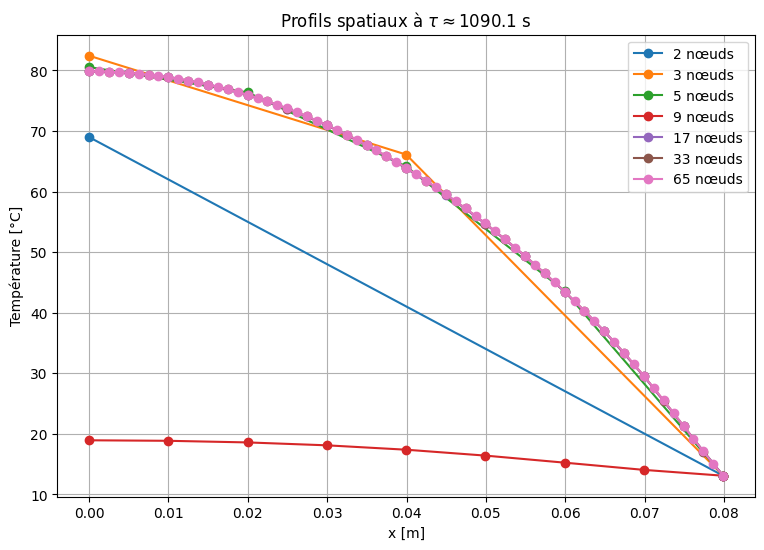

In [ ]:
# ============================================================
# GRAPHIQUE 5 : PROFILS SPATIAUX T(x,t)
# ============================================================

# Instant à visualiser.
# Par défaut : dernier instant disponible.
target_time_extra = tau_ice[-1]

plt.figure(figsize=(9, 6))

for result_mesh in mesh_results_extra:

    x_nodes = result_mesh["x_nodes"]
    saved_profiles = result_mesh["saved_profiles"]

    saved_indices = list(saved_profiles.keys())
    saved_times = np.array([tau_ice[idx] for idx in saved_indices])

    idx_closest_local = int(np.argmin(np.abs(saved_times - target_time_extra)))
    saved_index = saved_indices[idx_closest_local]

    T_profile = saved_profiles[saved_index]

    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"{result_mesh['N_nodes']} nœuds"
    )

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title(rf"Profils spatiaux à $\tau \approx {target_time_extra:.1f}$ s")
plt.grid(True)
plt.legend()
plt.show()